In [1]:
from world import World

WIDTH, HEIGHT = 100, 100

world = World(WIDTH, HEIGHT)

In [2]:
world.add_prey(number=20)
world.add_predator(number=10)

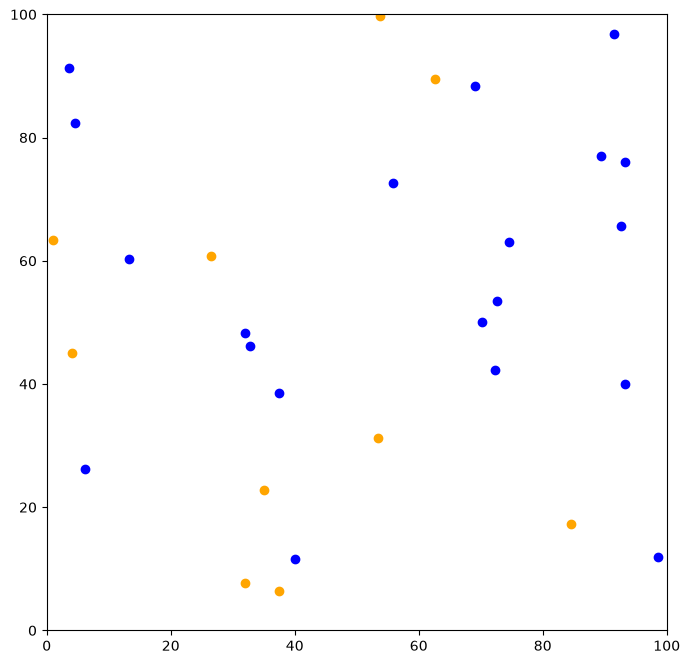

In [3]:
import matplotlib.pyplot as plt

# plot the world with the preys and predators
plt.figure(figsize=(8, 8))
plt.xlim(0, world.width)
plt.ylim(0, world.height)

for prey in world.preys:
    plt.scatter(prey.x, prey.y, c=world.color_prey)
for predator in world.predators:
    plt.scatter(predator.x, predator.y, c=world.color_predator)
plt.show()

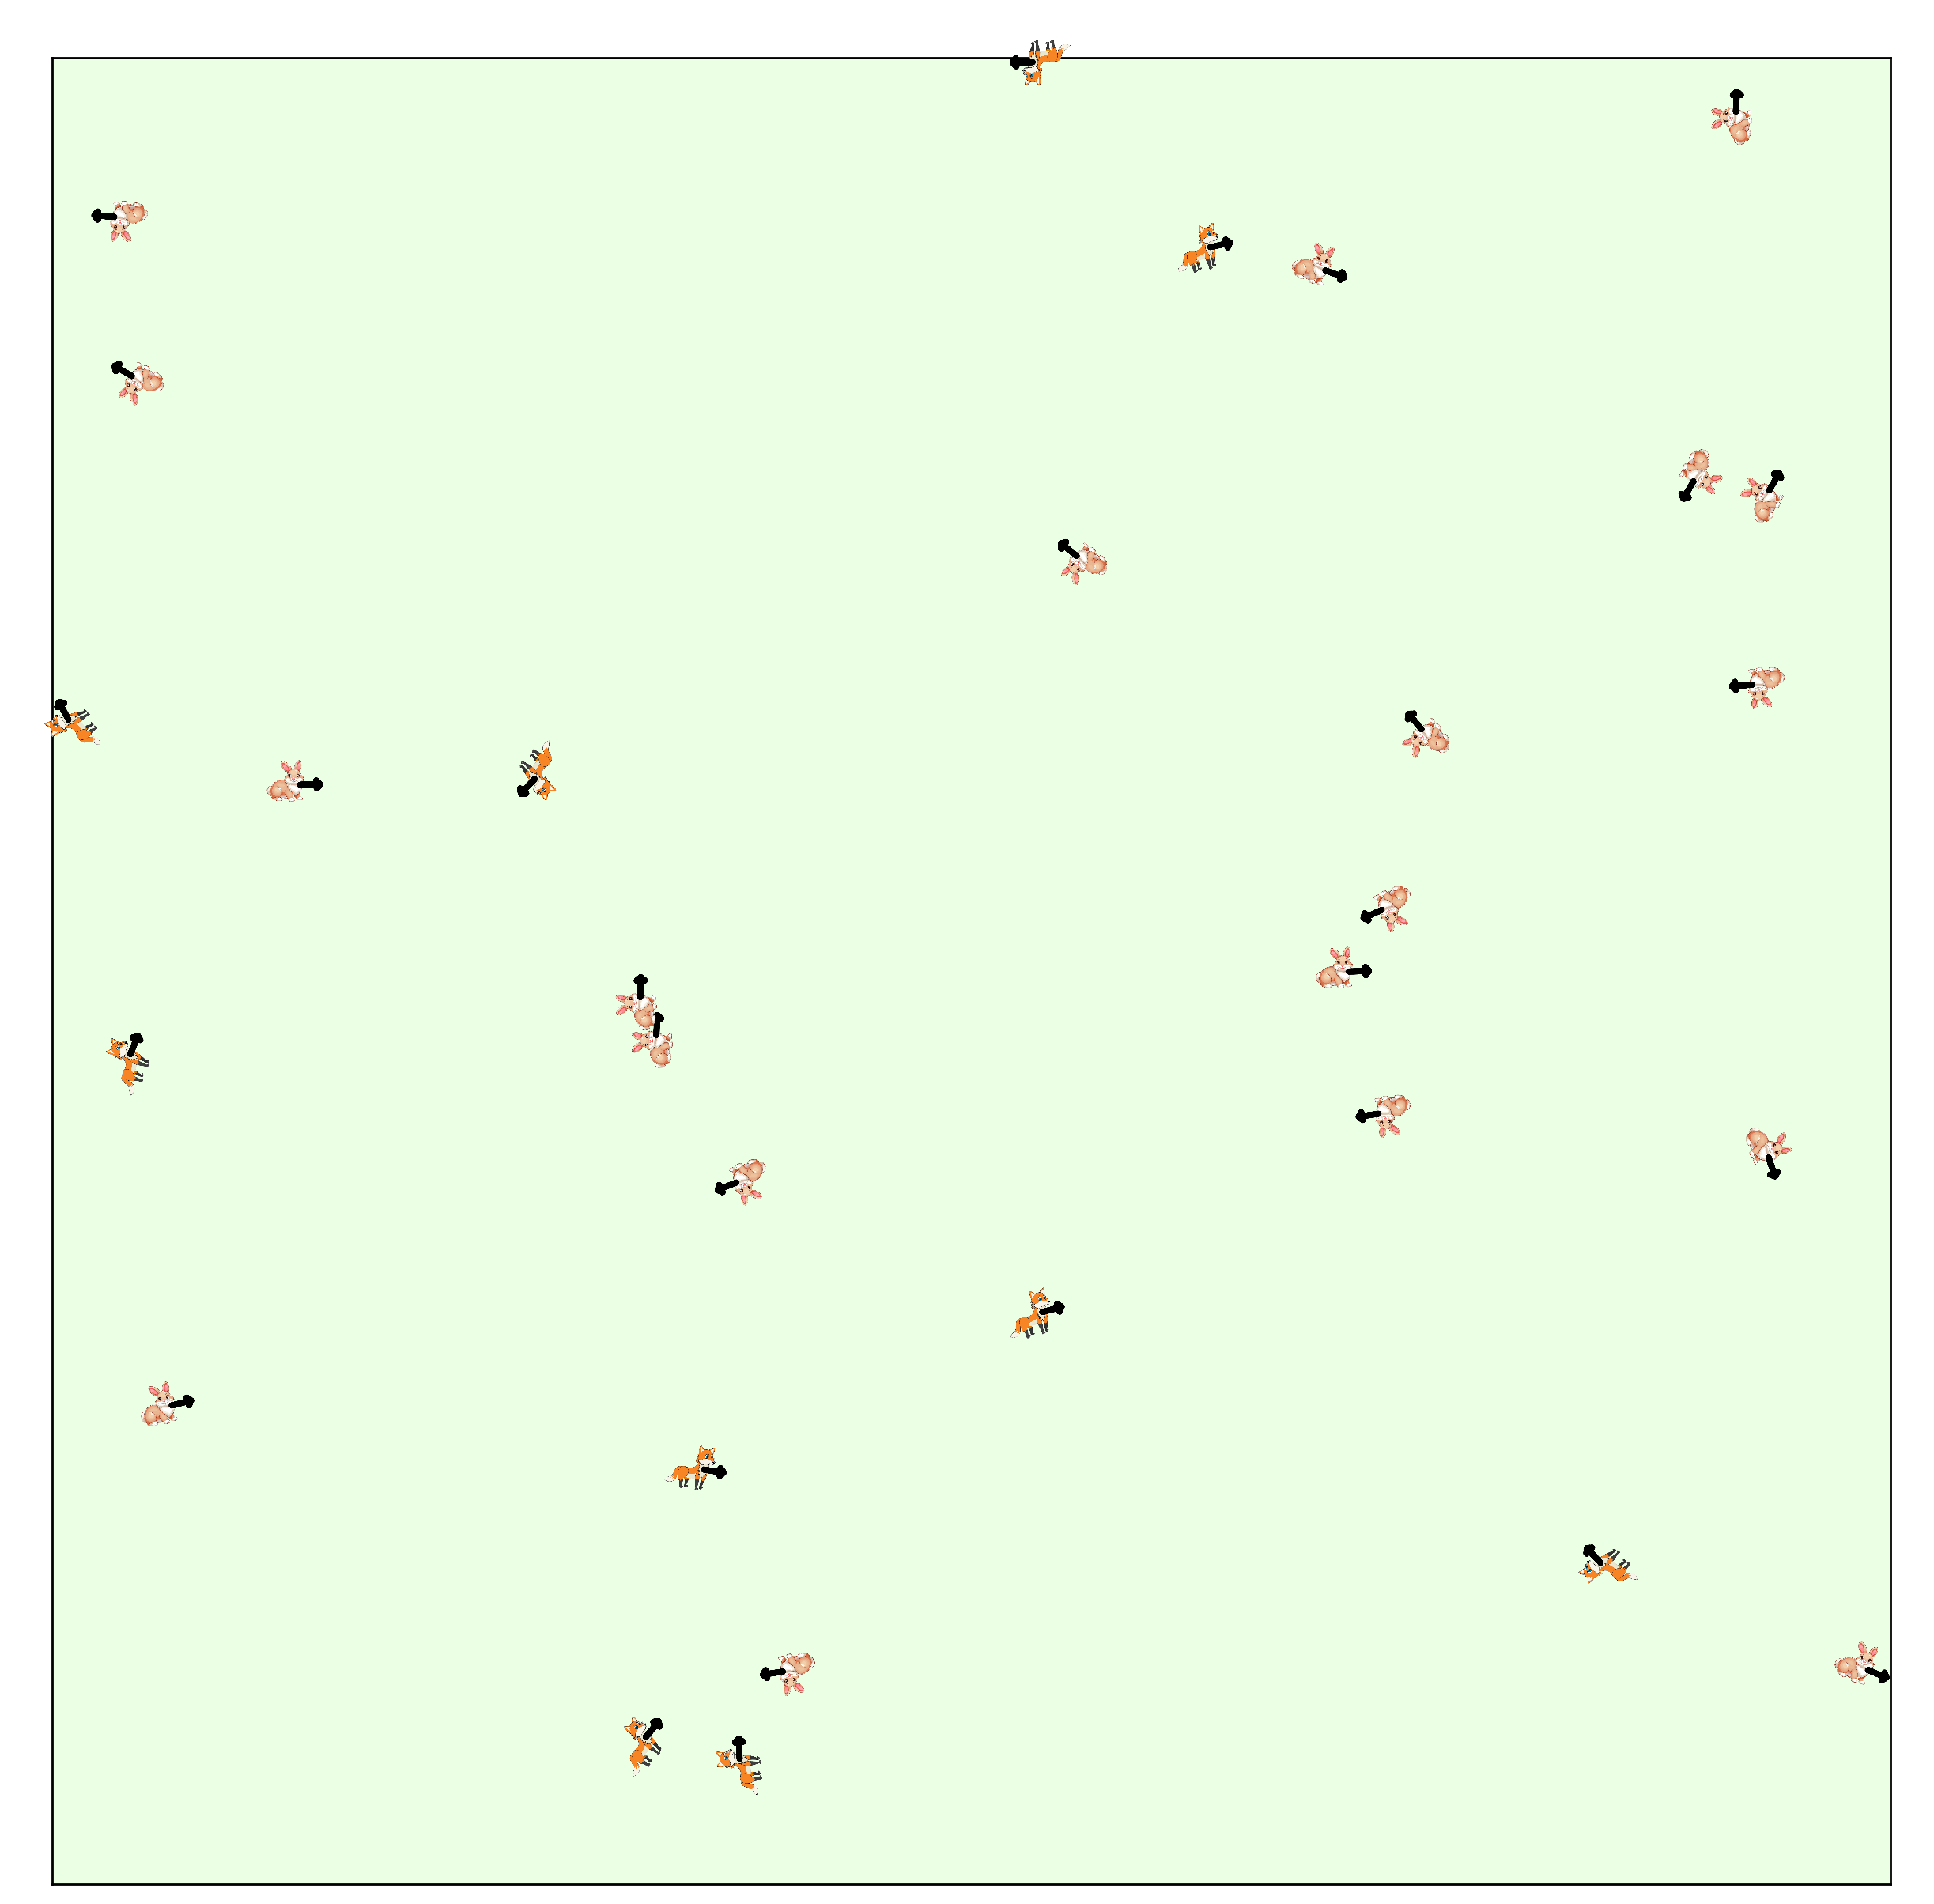

In [4]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import numpy as np


# Loading the images with PIL
hare_img = Image.open("./images/hare.png")
fox_img = Image.open("./images/fox.png")


plt.figure(figsize=(12, 12), dpi=250)
plt.xlim(0, world.width)
plt.ylim(0, world.height)

# initialization of the axes
ax = plt.gca()

# color of the background
ax.set_facecolor("#ebffe4")

# Hide the axes
ax.set_xticks([])
ax.set_yticks([])

for prey in world.preys:
    # Conversion in degree
    direction = prey.direction*180/np.pi  
    # Rotation of the image
    rotated_img = hare_img.rotate(
        -direction,
        resample=Image.Resampling.BICUBIC,
        expand=True
    )

    hare_icon = OffsetImage(
        np.array(rotated_img),
        zoom=0.05
    )

    ab = AnnotationBbox(
        hare_icon,
        (prey.x, prey.y),
        frameon=False
    )

    ax.add_artist(ab)


for predator in world.predators:

    direction = predator.direction*180/np.pi

    rotated_img = fox_img.rotate(
        -direction,
        resample=Image.Resampling.BICUBIC,
        expand=True
    )

    fox_icon = OffsetImage(
        np.array(rotated_img),
        zoom=0.05
    )

    ab = AnnotationBbox(
        fox_icon,
        (predator.x, predator.y),
        frameon=False
    )

    ax.add_artist(ab)


plt.show()

In [5]:
from tqdm import tqdm

def run_simulation(world, N):
    """Run the simulation and store the state at each time step."""
    history = {}
    pbar = tqdm(range(N), desc="Simulation")

    for i, t in enumerate(pbar):

        list_history = world.step()

        history[t] = list_history
        # index :
        # 0 : number of preys
        # 1 : number of predators
        # 2 : number of preys added
        # 3 : number of predators added
        # 4 : number of preys removed
        # 5 : number of predators removed
        # 6 : mean prey energy
        # 7 : mean predator energy

        # if there is no prey or no predator, we stop the simulation
        if list_history[0] == 0:
            print(f"Simulation stopped at time step {t} because there are no more preys.")
            break
        if list_history[1] == 0:
            print(f"Simulation stopped at time step {t} because there are no more predators.")
            break
        
    return history, i


# reset the world
world.remove_all_agents()

# inital conditions
world.add_prey(number=100)
world.add_predator(number=5)

# Hyperparameters

# Speed of the prey and predator
speed_prey = 1.0
world.speed_prey = speed_prey

speed_predator = 1.6
world.speed_predator = speed_predator

# energy needed for reproduction
world.reproduction_energy_needed_prey = 150
world.reproduction_energy_needed_predator = 150

# energy cost for reproduction
world.reproduction_energy_cost_prey = 50
world.reproduction_energy_cost_predator = 50

# energy gain by a predator when it eats a prey
world.energy_gain_predator = 20

# energy gain by a prey at each time step
world.energy_gain_prey = 1

# energy lost by a predator at each time step
world.energy_loss_predator = 1

# distance at which a prey will run away from a predator
world.distance_danger = 5.

# maximum number of preys and predators in the world
world.max_preys = 100
world.max_predators = 10

# max number of time steps
T = 2000

history, T = run_simulation(world, T)

Simulation:  16%|█▋        | 328/2000 [00:05<00:29, 56.63it/s] 

Simulation stopped at time step 328 because there are no more predators.


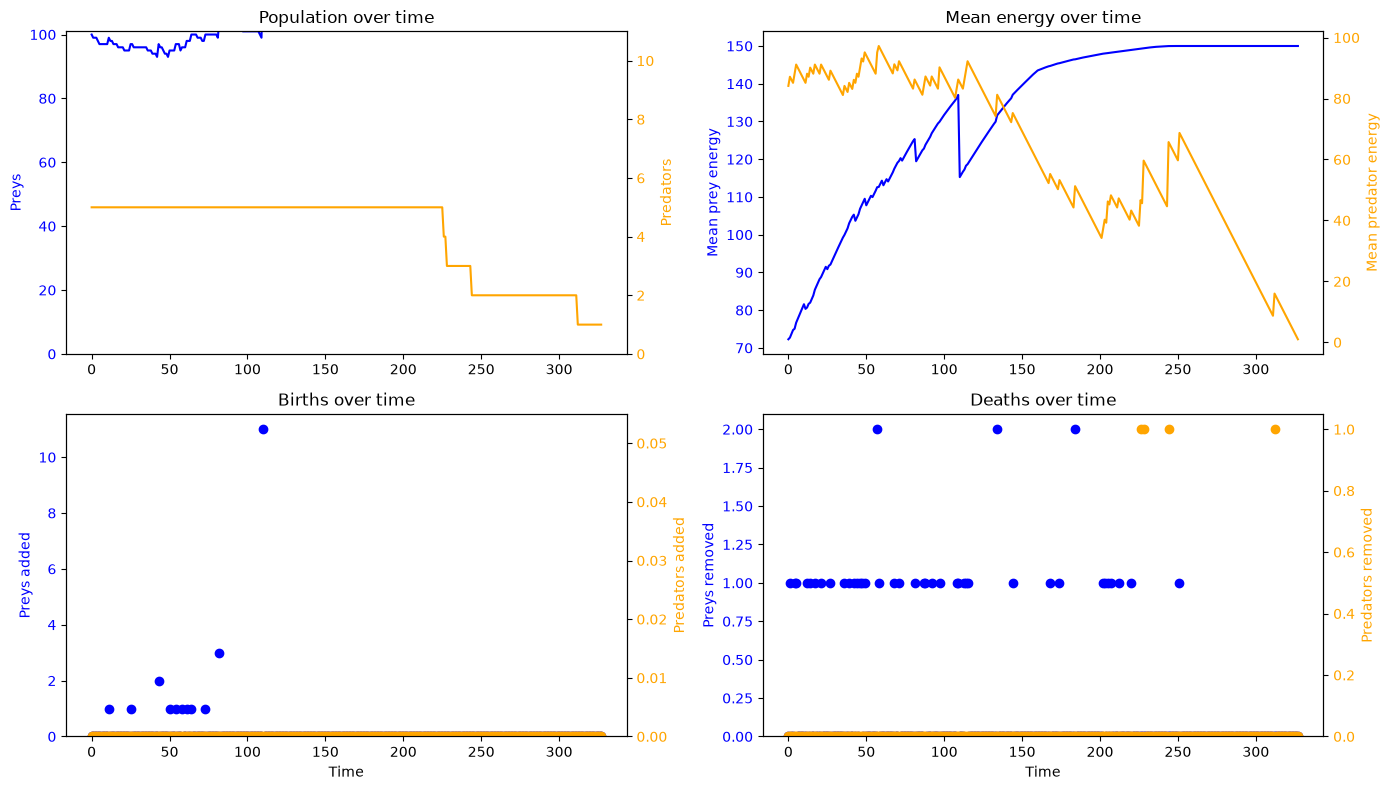

In [9]:
import matplotlib.pyplot as plt

# Extraction of the data from history
prey_counts = [history[t][0] for t in range(T)]
predator_counts = [history[t][1] for t in range(T)]
prey_added = [history[t][2] for t in range(T)]
predator_added = [history[t][3] for t in range(T)]
prey_removed = [history[t][4] for t in range(T)]
predator_removed = [history[t][5] for t in range(T)]
prey_mean_energy = [history[t][6] for t in range(T)]
predator_mean_energy = [history[t][7] for t in range(T)]

color_prey = world.color_prey
color_predator = world.color_predator

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
(ax1, ax3), (ax5, ax6) = axes

# --- Subplot 1 (top left) : populations ---
ax1.set_ylabel('Preys', color=color_prey)
ax1.plot(range(T), prey_counts, color=color_prey)
ax1.tick_params(axis='y', labelcolor=color_prey)
ax1.set_ylim(0, world.max_preys + 1)
ax1.set_title("Population over time")

ax2 = ax1.twinx()
ax2.set_ylabel('Predators', color=color_predator)
ax2.plot(range(T), predator_counts, color=color_predator)
ax2.tick_params(axis='y', labelcolor=color_predator)
ax2.set_ylim(0, world.max_predators + 1)

# --- Subplot 2 (top right) : mean energy ---
ax3.set_ylabel('Mean prey energy', color=color_prey)
ax3.plot(range(T), prey_mean_energy, color=color_prey)
ax3.tick_params(axis='y', labelcolor=color_prey)
ax3.set_title("Mean energy over time")

ax4 = ax3.twinx()
ax4.set_ylabel('Mean predator energy', color=color_predator)
ax4.plot(range(T), predator_mean_energy, color=color_predator)
ax4.tick_params(axis='y', labelcolor=color_predator)

# --- Subplot 3 (bottom left) : births ---
ax5.set_xlabel('Time')
ax5.set_ylabel('Preys added', color=color_prey)
ax5.scatter(range(T), prey_added, color=color_prey)
ax5.tick_params(axis='y', labelcolor=color_prey)
ax5.set_ylim(bottom=0)
ax5.set_title("Births over time")

ax5b = ax5.twinx()
ax5b.set_ylabel('Predators added', color=color_predator)
ax5b.scatter(range(T), predator_added, color=color_predator)
ax5b.set_ylim(bottom=0)
ax5b.tick_params(axis='y', labelcolor=color_predator)

# --- Subplot 4 (bottom right) : deaths ---
ax6.set_xlabel('Time')
ax6.set_ylabel('Preys removed', color=color_prey)
ax6.scatter(range(T), prey_removed, color=color_prey)
ax6.tick_params(axis='y', labelcolor=color_prey)
ax6.set_ylim(bottom=0)
ax6.set_title("Deaths over time")

ax6b = ax6.twinx()
ax6b.set_ylabel('Predators removed', color=color_predator)
ax6b.scatter(range(T), predator_removed, color=color_predator)
ax6b.tick_params(axis='y', labelcolor=color_predator)
ax6b.set_ylim(bottom=0)

fig.tight_layout()
plt.show()

In [7]:
prey_removed = [history[t][4] for t in range(T)]
predator_removed = [history[t][5] for t in range(T)]

prey_added = [history[t][2] for t in range(T)]
predator_added = [history[t][3] for t in range(T)]

for t in range(100):
    print(prey_added[t], predator_added[t])

    

0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
1 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
1 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
2 0
0 0
0 0
0 0
0 0
0 0
0 0
1 0
0 0
0 0
0 0
1 0
0 0
0 0
0 0
1 0
0 0
0 0
1 0
0 0
0 0
1 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
1 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
3 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0
0 0


In [8]:
fbgyt

NameError: name 'fbgyt' is not defined

In [ ]:
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"

import pygame
import numpy as np
import imageio


def render_simulation(
    history,
    world_width,
    world_height,
    output_path="./plot/world.gif",
    scale=8,
    output_size=(800, 800),
    sprite_size_physical=3,
    fps=2,
    bg_color=(235, 255, 228),
    hare_path="./images/hare.png",
    fox_path="./images/fox.png",
):
    """Read a simulation history and generate a GIF, without ever touching `world`."""

    pygame.init()
    pygame.display.set_mode((1, 1))

    render_width = int(world_width * scale)
    render_height = int(world_height * scale)
    sprite_size_px = int(sprite_size_physical * scale)

    screen = pygame.Surface((render_width, render_height))

    hare_img = pygame.image.load(hare_path).convert_alpha()
    fox_img = pygame.image.load(fox_path).convert_alpha()
    hare_img = pygame.transform.smoothscale(hare_img, (sprite_size_px, sprite_size_px))
    fox_img = pygame.transform.smoothscale(fox_img, (sprite_size_px, sprite_size_px))

    def to_pixels(x, y):
        px = x * scale
        py = render_height - (y * scale)
        return px, py

    frames = []

    for t in sorted(history.keys()):
        dict_agent = history[t]

        screen.fill(bg_color)

        for x, y, theta in dict_agent["preys"]:
            angle_deg = np.degrees(theta)
            rotated = pygame.transform.rotate(hare_img, angle_deg)
            px, py = to_pixels(x, y)
            rect = rotated.get_rect(center=(px, py))
            screen.blit(rotated, rect)

        for x, y, theta in dict_agent["predators"]:
            angle_deg = np.degrees(theta)
            rotated = pygame.transform.rotate(fox_img, angle_deg)
            px, py = to_pixels(x, y)
            rect = rotated.get_rect(center=(px, py))
            screen.blit(rotated, rect)

        final_surface = pygame.transform.smoothscale(screen, output_size)
        frame_array = pygame.surfarray.array3d(final_surface)
        frame_array = np.transpose(frame_array, (1, 0, 2))
        frames.append(frame_array)

    pygame.quit()

    imageio.mimsave(output_path, frames, fps=fps)
    print(f"GIF saved : {output_path}")

pygame 2.6.1 (SDL 2.28.4, Python 3.12.3)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [ ]:
render_simulation(
    history,
    world_width=WIDTH,
    world_height=HEIGHT,
    output_path="./plot/world.gif",
    scale=8,
    output_size=(800, 800),
    sprite_size_physical=3,
    fps=5,
    bg_color=(235, 255, 228),
    hare_path="./images/hare.png",
    fox_path="./images/fox.png",
)   

GIF saved : ./plot/world.gif
